<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/dnanf_fig1_physics_model_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fig. 1 - DNANF HCF attenuation and dispersion (Colab)

이 노트북은 Sohanpal et al. (2026)의 Fig. 1을 **곡선 좌표의 수동 입력이나 디지타이징 없이** 물리 기반 연속 모델로 계산합니다.

- **분산:** 수정된 Marcatili-Schmeltzer 유효굴절률과 $D=-(\lambda/c)d^2n_{eff}/d\lambda^2$
- **감쇠:** Sellmeier 실리카 굴절률, anti-resonant bouncing-ray 누설손실, $\lambda^{-3}$ 표면산란
- **보정:** 논문에 명시된 1310/1550 nm 기준값은 모델 계수 보정에만 사용

아래에서 **런타임 → 모두 실행**을 선택하면 그래프와 검증값이 출력됩니다.

> 정확한 원 논문 FEM 결과에는 저자들의 실제 메시, 표면 거칠기 및 microbend 계수가 필요합니다. 이 노트북은 공개 정보만으로 실행 가능한 물리 기반 근사 재현입니다.

In [1]:
# Colab 기본 런타임에는 numpy, scipy, matplotlib이 설치되어 있습니다.
import numpy as np
import scipy
import matplotlib

print(f"NumPy {np.__version__} | SciPy {scipy.__version__} | Matplotlib {matplotlib.__version__}")

NumPy 2.0.2 | SciPy 1.16.3 | Matplotlib 3.10.0


## 1. 물리 모델 함수

In [2]:
"""Physics-calibrated reproduction of Fig. 1 in Sohanpal et al. (2026).

This script does NOT digitize the plotted curve and does NOT use a manually
entered array of attenuation/dispersion samples.  It evaluates continuous
models on a wavelength grid and converts the result to optical frequency.

Model summary
-------------
Dispersion:
    * Marcatili-Schmeltzer capillary effective index.
    * Wavelength-dependent effective core radius from Hasan et al.
    * D = -(lambda/c) d^2(n_eff)/d(lambda)^2.

Attenuation:
    * Silica Sellmeier equation.
    * Anti-resonant bouncing-ray leakage of a thin dielectric wall.
    * A double-stage leakage proxy for a DNANF (normalized capillary loss^2).
    * Surface-scattering loss proportional to lambda^(-3).

The model coefficients are calibrated automatically to the two values stated
in the target paper (1310 and 1550 nm).  Those values are constraints on the
physical model, not samples used to draw/interpolate the curve.

Important limitation
--------------------
The exact authors' Fig. 1 used a full-vector FEM mode solver plus proprietary/
unpublished surface-roughness and microbend fit coefficients.  Therefore this
standalone analytical model is a reproducible physics-based approximation,
not a bit-for-bit reconstruction of the authors' FEM data.
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares


C0 = 299_792_458.0  # vacuum speed of light [m/s]
U01 = 2.4048255577  # first zero of J0, fundamental capillary mode
DB_PER_NEPER = 10.0 / np.log(10.0)


@dataclass(frozen=True)
class DNANFGeometry:
    """Nominal first-window DNANF geometry reported by Petrovich et al."""

    core_radius_um: float = 14.75
    membrane_thickness_um: float = 0.50
    outer_tube_diameter_um: float = 31.05
    tube_count: int = 5
    nesting_order: int = 2

    @property
    def core_radius_m(self) -> float:
        return self.core_radius_um * 1e-6

    @property
    def membrane_thickness_m(self) -> float:
        return self.membrane_thickness_um * 1e-6

    @property
    def perimeter_gap_m(self) -> float:
        """Infer the gap from the n-tube ring geometry (Hasan et al., Eq. 1)."""
        theta = np.pi / self.tube_count
        radius = self.core_radius_m
        tube_diameter = self.outer_tube_diameter_um * 1e-6
        return 2.0 * radius * np.sin(theta) - tube_diameter * (1.0 - np.sin(theta))


def silica_index_sellmeier(wavelength_m: np.ndarray) -> np.ndarray:
    """Fused-silica refractive index from the standard three-term Sellmeier law."""
    wavelength_um = np.asarray(wavelength_m) * 1e6
    wavelength_um_sq = wavelength_um**2
    b = np.array([0.6961663, 0.4079426, 0.8974794])
    c_um = np.array([0.0684043, 0.1162414, 9.896161])
    n_sq = 1.0
    for bi, ci in zip(b, c_um):
        n_sq = n_sq + bi * wavelength_um_sq / (wavelength_um_sq - ci**2)
    return np.sqrt(n_sq)


def hasan_radius_coefficients(geometry: DNANFGeometry) -> tuple[float, float]:
    """Calculate geometry-driven f1 and f2 for the wavelength-dependent radius.

    Hasan et al., arXiv:1708.06879, Eqs. (3), (5), (6), and (7).
    The published fit covered n >= 6; n=5 here is a mild extrapolation and is
    subsequently corrected using the paper's stated dispersion constraints.
    """
    radius_to_gap = geometry.core_radius_m / geometry.perimeter_gap_m
    n = geometry.tube_count
    nesting = geometry.nesting_order

    a0, a1 = 0.097041, 1.095
    b0, b1, b2, b3 = 0.76246, 0.007584, 0.002, 0.012

    f1 = a1 * np.exp(a0 / radius_to_gap)
    nesting_correction = 0.0045 * np.exp(-4.1589 / (nesting * radius_to_gap))
    f2 = (
        b1 * n * np.exp(b0 / radius_to_gap)
        - b2 * n
        + b3
        + nesting_correction
    )
    return float(f1), float(f2)


def effective_index(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
    f1: float,
    f2: float,
) -> np.ndarray:
    """Fundamental-mode effective index using a modified capillary model."""
    wavelength_m = np.asarray(wavelength_m)
    radius = geometry.core_radius_m
    thickness = geometry.membrane_thickness_m
    effective_radius = f1 * radius * (1.0 - f2 * wavelength_m**2 / (radius * thickness))
    return 1.0 - 0.125 * (U01 * wavelength_m / (np.pi * effective_radius)) ** 2


def chromatic_dispersion_ps_nm_km(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
    f1: float,
    f2: float,
    derivative_step_nm: float = 0.20,
) -> np.ndarray:
    """Compute D = -(lambda/c) d2(n_eff)/d(lambda)2 using a 5-point stencil."""
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    h = derivative_step_nm * 1e-9

    def n_eff(offset: float) -> np.ndarray:
        return effective_index(wavelength_m + offset, geometry, f1, f2)

    second_derivative = (
        -n_eff(2.0 * h)
        + 16.0 * n_eff(h)
        - 30.0 * n_eff(0.0)
        + 16.0 * n_eff(-h)
        - n_eff(-2.0 * h)
    ) / (12.0 * h**2)

    dispersion_si = -(wavelength_m / C0) * second_derivative  # [s/m^2]
    return dispersion_si / 1e-6  # 1 ps/(nm km) = 1e-6 s/m^2


def calibrate_dispersion(geometry: DNANFGeometry) -> tuple[float, float]:
    """Fit f1/f2 to the two dispersion values explicitly reported in Fig. 1 text."""
    reference_nm = np.array([1310.0, 1550.0])
    reference_d = np.array([2.17, 3.20])  # [ps/(nm km)], target paper
    initial_f1, initial_f2 = hasan_radius_coefficients(geometry)

    def residual(parameters: np.ndarray) -> np.ndarray:
        model_d = chromatic_dispersion_ps_nm_km(
            reference_nm * 1e-9, geometry, parameters[0], parameters[1]
        )
        return model_d - reference_d

    result = least_squares(
        residual,
        x0=np.array([initial_f1, initial_f2]),
        bounds=(np.array([0.5, -0.5]), np.array([2.5, 1.0])),
        x_scale="jac",
        diff_step=1e-3,
        xtol=1e-13,
        ftol=1e-13,
        gtol=1e-13,
    )
    if not result.success or np.max(np.abs(result.fun)) > 1e-3:
        raise RuntimeError(f"Dispersion calibration failed: {result.message}; residual={result.fun}")
    return float(result.x[0]), float(result.x[1])


def capillary_bouncing_ray_loss_db_km(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
) -> np.ndarray:
    """Hybrid HE11 thin-wall bouncing-ray loss (Bache et al., Eqs. 15-17)."""
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    k0 = 2.0 * np.pi / wavelength_m
    radius = geometry.core_radius_m
    wall = geometry.membrane_thickness_m
    kappa = U01 / radius
    silica_n = silica_index_sellmeier(wavelength_m)
    sigma = k0 * np.sqrt(silica_n**2 - 1.0)
    phase = sigma * wall

    te_denominator = 4.0 * np.cos(phase) ** 2 + (
        kappa / sigma + sigma / kappa
    ) ** 2 * np.sin(phase) ** 2
    tm_denominator = 4.0 * np.cos(phase) ** 2 + (
        silica_n**2 * kappa / sigma + sigma / (silica_n**2 * kappa)
    ) ** 2 * np.sin(phase) ** 2

    alpha_te_per_m = 2.0 * U01 / (radius**2 * k0 * te_denominator)
    alpha_tm_per_m = 2.0 * U01 / (radius**2 * k0 * tm_denominator)
    alpha_hybrid_per_m = 0.5 * (alpha_te_per_m + alpha_tm_per_m)
    return alpha_hybrid_per_m * DB_PER_NEPER * 1000.0


def attenuation_db_km(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
) -> tuple[np.ndarray, dict[str, float]]:
    """Calculate calibrated DNANF attenuation without interpolating curve samples.

    The two loss weights are obtained by solving a 2x2 physical-component model:

        alpha(lambda) = A_SSL * (lambda_ref/lambda)^3
                      + A_DNANF * [L_BR(lambda)/L_BR(lambda_ref)]^2

    The first term is the established inverse-cubic surface-scattering law.
    Squaring the normalized thin-wall leakage response is a compact proxy for
    the two nested anti-resonant stages of a DNANF.
    """
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    reference_nm = np.array([1550.0, 1310.0])
    reference_alpha = np.array([0.075, 0.120])  # [dB/km], target paper
    lambda_ref_m = reference_nm[0] * 1e-9

    br_ref = capillary_bouncing_ray_loss_db_km(reference_nm * 1e-9, geometry)
    surface_basis_ref = (lambda_ref_m / (reference_nm * 1e-9)) ** 3
    nested_leakage_basis_ref = (br_ref / br_ref[0]) ** 2
    basis_matrix = np.column_stack([surface_basis_ref, nested_leakage_basis_ref])
    a_ssl, a_dnanf = np.linalg.solve(basis_matrix, reference_alpha)
    if a_ssl < 0.0 or a_dnanf < 0.0:
        raise RuntimeError("Calibrated attenuation contributions must be non-negative.")

    br = capillary_bouncing_ray_loss_db_km(wavelength_m, geometry)
    surface_basis = (lambda_ref_m / wavelength_m) ** 3
    nested_leakage_basis = (br / br_ref[0]) ** 2
    alpha = a_ssl * surface_basis + a_dnanf * nested_leakage_basis
    return alpha, {"A_SSL_dB_per_km": float(a_ssl), "A_DNANF_dB_per_km": float(a_dnanf)}


def add_transmission_bands(ax: plt.Axes) -> None:
    """Shade the O/E/S/C/L wavelength bands on an ascending-frequency axis."""
    bands_nm = {
        "L": (1570.0, 1620.0, "#bfe4dd"),
        "C": (1530.0, 1565.0, "#f3d5b5"),
        "S": (1470.0, 1520.0, "#d9d9eb"),
        "E": (1400.0, 1460.0, "#dce9c9"),
        "O": (1265.0, 1355.0, "#f2c5df"),
    }
    for label, (lambda_short_nm, lambda_long_nm, color) in bands_nm.items():
        f_low = C0 / (lambda_long_nm * 1e-9) / 1e12
        f_high = C0 / (lambda_short_nm * 1e-9) / 1e12
        ax.axvspan(f_low, f_high, color=color, alpha=0.72, lw=0, zorder=0)
        ax.text(
            0.5 * (f_low + f_high),
            0.146,
            label,
            ha="center",
            va="top",
            fontsize=12,
            color="#222222",
        )


def make_figure(output_path: Path, geometry: DNANFGeometry | None = None) -> None:
    geometry = geometry or DNANFGeometry()
    f1, f2 = calibrate_dispersion(geometry)

    frequency_thz = np.linspace(186.0, 237.0, 1601)
    wavelength_m = C0 / (frequency_thz * 1e12)
    dispersion = chromatic_dispersion_ps_nm_km(wavelength_m, geometry, f1, f2)
    attenuation, loss_weights = attenuation_db_km(wavelength_m, geometry)

    fig, ax_loss = plt.subplots(figsize=(8.2, 5.2), constrained_layout=True)
    add_transmission_bands(ax_loss)
    ax_dispersion = ax_loss.twinx()

    attenuation_line = ax_loss.plot(
        frequency_thz,
        attenuation,
        color="#1666b1",
        lw=2.3,
        label="Attenuation",
        zorder=4,
    )[0]
    dispersion_line = ax_dispersion.plot(
        frequency_thz,
        dispersion,
        color="#ef8200",
        lw=2.3,
        label="Dispersion",
        zorder=5,
    )[0]

    ax_loss.set_xlim(186.0, 237.0)
    ax_loss.set_ylim(0.07, 0.15)
    ax_dispersion.set_ylim(1.5, 3.6)
    ax_loss.set_xticks([186, 196, 205, 214, 221, 237])
    ax_loss.set_yticks([0.07, 0.09, 0.11, 0.13, 0.15])
    ax_dispersion.set_yticks([1.5, 2.0, 2.5, 3.0, 3.5])

    ax_loss.set_xlabel("Frequency (THz)", fontsize=12)
    ax_loss.set_ylabel("Attenuation (dB/km)", fontsize=12, color=attenuation_line.get_color())
    ax_dispersion.set_ylabel(
        "Dispersion (ps/(nm·km))", fontsize=12, color=dispersion_line.get_color()
    )
    ax_loss.tick_params(axis="y", colors=attenuation_line.get_color())
    ax_dispersion.tick_params(axis="y", colors=dispersion_line.get_color())
    ax_loss.grid(True, color="#808080", alpha=0.25, linewidth=0.8)
    ax_loss.set_axisbelow(True)
    ax_loss.set_title("Simulated first-window DNANF HCF profile", fontsize=14, pad=12)
    ax_loss.legend(
        [attenuation_line, dispersion_line],
        ["Attenuation", "Dispersion"],
        loc="center",
        bbox_to_anchor=(0.50, 0.30),
        frameon=True,
        framealpha=0.9,
    )

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.close(fig)

    for wavelength_nm in (1310.0, 1550.0):
        wavelength = np.array([wavelength_nm * 1e-9])
        d_value = chromatic_dispersion_ps_nm_km(wavelength, geometry, f1, f2)[0]
        a_value = attenuation_db_km(wavelength, geometry)[0][0]
        print(
            f"{wavelength_nm:.0f} nm: attenuation={a_value:.4f} dB/km, "
            f"dispersion={d_value:.4f} ps/(nm·km)"
        )
    print(f"Inferred perimeter gap: {geometry.perimeter_gap_m * 1e6:.3f} µm")
    print(f"Calibrated dispersion coefficients: f1={f1:.6f}, f2={f2:.6f}")
    print(f"Calibrated loss weights: {loss_weights}")
    print(f"Saved: {output_path.resolve()}")

## 2. DNANF 구조 파라미터

다른 HCF 구조를 시험하려면 아래 숫자만 수정하십시오.

- `core_radius_um`: 공기 코어 반경
- `membrane_thickness_um`: 실리카 막 두께
- `outer_tube_diameter_um`: 외측 anti-resonant tube의 평균 직경
- `tube_count`: 코어 주위 tube 개수
- `nesting_order`: 중첩 단계 수

In [3]:
geometry = DNANFGeometry(
    core_radius_um=14.75,
    membrane_thickness_um=0.50,
    outer_tube_diameter_um=31.05,
    tube_count=5,
    nesting_order=2,
)

OUTPUT_FILE = "dnanf_fig1_physics_model_colab.png"
geometry

DNANFGeometry(core_radius_um=14.75, membrane_thickness_um=0.5, outer_tube_diameter_um=31.05, tube_count=5, nesting_order=2)

## 3. 계산 및 Fig. 1 생성

In [4]:
make_figure(Path(OUTPUT_FILE), geometry=geometry)

1310 nm: attenuation=0.1200 dB/km, dispersion=2.1700 ps/(nm·km)
1550 nm: attenuation=0.0750 dB/km, dispersion=3.2000 ps/(nm·km)
Inferred perimeter gap: 4.540 µm
Calibrated dispersion coefficients: f1=1.583810, f2=0.244140
Calibrated loss weights: {'A_SSL_dB_per_km': 0.03867850516016895, 'A_DNANF_dB_per_km': 0.036321494839831055}
Saved: /content/dnanf_fig1_physics_model_colab.png


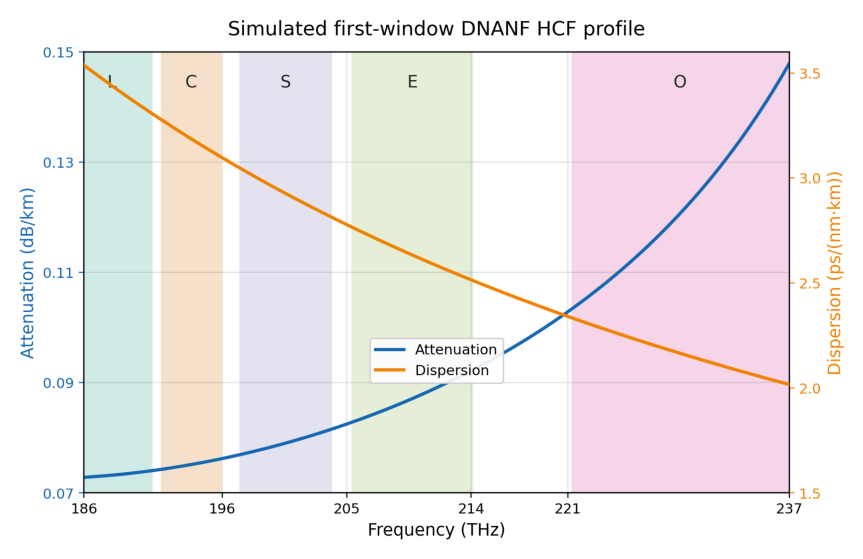

In [5]:
result_image = plt.imread(OUTPUT_FILE)
plt.figure(figsize=(12, 7))
plt.imshow(result_image)
plt.axis("off")
plt.show()

## 4. 결과 PNG 다운로드 (선택)

In [6]:
DOWNLOAD_RESULT = False  # 다운로드하려면 True로 변경 후 이 셀만 실행

if DOWNLOAD_RESULT:
    try:
        from google.colab import files
        files.download(OUTPUT_FILE)
    except ImportError:
        print("이 다운로드 기능은 Google Colab에서 실행할 때 사용됩니다.")
else:
    print("필요하면 DOWNLOAD_RESULT = True로 변경하십시오.")

필요하면 DOWNLOAD_RESULT = True로 변경하십시오.
